# Bird Species Observation Analysis — Exploratory Data Analysis (EDA)

**Domain:** Environmental Studies, Biodiversity Conservation & Ecology
**Data:** Forest & Grassland bird monitoring surveys across 11 National Park
Service administrative units (2018 breeding-bird point counts).

This notebook covers the **Data Cleaning** and **Exploratory Data Analysis**
stages of the project (per the project brief). The **interactive Streamlit
dashboard** is a separate deliverable (`app.py`) that lets a user upload a
raw workbook and explore it live — this notebook is the offline, narrative
analysis that documents *how* the data was cleaned and *what* it shows.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


### Cleaning pipeline (embedded)

This notebook is self-contained: the same cleaning pipeline that ships in
`utils/data_processing.py` (and is used by the Streamlit dashboard) is
embedded directly below, so this notebook runs correctly even if it's
opened on its own, outside of the project folder structure.

In [2]:
"""
data_processing.py
-------------------
Reusable data cleaning / preprocessing pipeline for the Bird Species
Observation Analysis project.

This module is imported by BOTH:
  1. The EDA notebook / script (offline analysis)
  2. The Streamlit dashboard (app.py) -> so that whatever file a user
     uploads goes through the exact same, tested cleaning logic.

Design goal: the pipeline should work on:
  - The original "Bird_Monitoring_Data_FOREST.XLSX" (multi-sheet, one
    sheet per Admin_Unit_Code)
  - The original "Bird_Monitoring_Data_GRASSLAND.XLSX" (same structure)
  - Any similarly-structured excel file a user uploads later, even if
    it only has some of the columns, or a single sheet.
"""

from __future__ import annotations

import io
import re
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# Column harmonisation
# ---------------------------------------------------------------------------
# The two source files are almost identical but not quite:
#   FOREST has:    Site_Name, NPSTaxonCode
#   GRASSLAND has: TaxonCode, Previously_Obs
# We map both "taxon code" variants onto a single canonical column name,
# and make sure every optional column exists (filled with NaN) so the two
# habitats can be safely concatenated.

CANONICAL_COLUMNS = [
    "Admin_Unit_Code", "Sub_Unit_Code", "Site_Name", "Plot_Name",
    "Location_Type", "Year", "Date", "Start_Time", "End_Time", "Observer",
    "Visit", "Interval_Length", "ID_Method", "Distance", "Flyover_Observed",
    "Sex", "Common_Name", "Scientific_Name", "AcceptedTSN", "TaxonCode",
    "AOU_Code", "PIF_Watchlist_Status", "Regional_Stewardship_Status",
    "Temperature", "Humidity", "Sky", "Wind", "Disturbance",
    "Previously_Obs", "Initial_Three_Min_Cnt",
]

RENAME_MAP = {
    "NPSTaxonCode": "TaxonCode",
}

BOOL_LIKE_COLUMNS = [
    "Flyover_Observed", "PIF_Watchlist_Status", "Regional_Stewardship_Status",
    "Previously_Obs", "Initial_Three_Min_Cnt",
]

TEXT_COLUMNS = [
    "Admin_Unit_Code", "Site_Name", "Plot_Name", "Location_Type",
    "Observer", "Interval_Length", "ID_Method", "Distance", "Sex",
    "Common_Name", "Scientific_Name", "AOU_Code", "Sky", "Wind",
    "Disturbance",
]


def _to_bool(series: pd.Series) -> pd.Series:
    """Coerce a messy TRUE/FALSE/1/0/yes/no-like column to real booleans,
    keeping NaN where the value is genuinely missing."""
    mapping = {
        "true": True, "false": False, "1": True, "0": False,
        "yes": True, "no": False, "t": True, "f": False,
    }

    def conv(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, (bool, np.bool_)):
            return bool(v)
        if isinstance(v, (int, float)):
            return bool(v)
        return mapping.get(str(v).strip().lower(), np.nan)

    return series.apply(conv)


def load_workbook(file_like, habitat_hint: str | None = None) -> pd.DataFrame:
    """Load every sheet of an uploaded / on-disk Excel workbook and stack
    them into a single long DataFrame.

    Parameters
    ----------
    file_like: path string, bytes, or a file-like object (e.g. what
        st.file_uploader gives you).
    habitat_hint: optional string ("Forest" / "Grassland") used as a
        fallback for the Location_Type column if a sheet is missing it.
    """
    xls = pd.ExcelFile(file_like)
    frames = []
    for sheet in xls.sheet_names:
        df = xls.parse(sheet)
        if df.empty:
            continue
        df["__source_sheet"] = sheet
        frames.append(df)

    if not frames:
        raise ValueError("No non-empty sheets were found in this workbook.")

    combined = pd.concat(frames, ignore_index=True, sort=False)

    # Harmonise column names (e.g. NPSTaxonCode -> TaxonCode)
    combined = combined.rename(columns=RENAME_MAP)

    # Make sure every canonical column exists, even if this particular
    # workbook doesn't have it, so downstream code never KeyErrors.
    for col in CANONICAL_COLUMNS:
        if col not in combined.columns:
            combined[col] = np.nan

    if habitat_hint and combined["Location_Type"].isna().all():
        combined["Location_Type"] = habitat_hint

    return combined


def clean_bird_data(raw: pd.DataFrame, drop_exact_duplicates: bool = True) -> pd.DataFrame:
    """Apply the full cleaning / preprocessing pipeline to a raw,
    concatenated bird-observation DataFrame and return an analysis-ready
    copy. Non-destructive: does not mutate the input.
    """
    df = raw.copy()

    # --- 1. Standardise column presence -----------------------------------
    for col in CANONICAL_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan

    # --- 2. Drop fully-empty helper columns / exact duplicate rows --------
    dup_count = 0
    if drop_exact_duplicates:
        subset_cols = [c for c in df.columns if c != "__source_sheet"]
        before = len(df)
        df = df.drop_duplicates(subset=subset_cols, keep="first")
        dup_count = before - len(df)

    # --- 3. Parse dates / times ---------------------------------------------
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    def parse_time(col):
        # Handles both datetime.time objects and "HH:MM:SS" strings
        parsed = pd.to_datetime(df[col].astype(str), errors="coerce", format="mixed")
        return parsed.dt.time

    for tcol in ["Start_Time", "End_Time"]:
        try:
            df[tcol] = parse_time(tcol)
        except Exception:
            pass  # leave as-is if unparseable; charts will just skip NaT

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    # Derive Year from Date where missing / inconsistent
    df["Year"] = df["Year"].fillna(df["Date"].dt.year)

    df["Month"] = df["Date"].dt.month
    df["Month_Name"] = df["Date"].dt.month_name()
    df["Day_of_Week"] = df["Date"].dt.day_name()

    season_map = {12: "Winter", 1: "Winter", 2: "Winter",
                  3: "Spring", 4: "Spring", 5: "Spring",
                  6: "Summer", 7: "Summer", 8: "Summer",
                  9: "Fall", 10: "Fall", 11: "Fall"}
    df["Season"] = df["Month"].map(season_map)

    # Observation start hour -> useful for "time of day" analysis
    df["Start_Hour"] = df["Start_Time"].apply(
        lambda t: t.hour if pd.notna(t) and hasattr(t, "hour") else np.nan
    )

    # --- 4. Standardise text / categorical columns -------------------------
    for col in TEXT_COLUMNS:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .replace({"": pd.NA, "nan": pd.NA, "NaN": pd.NA})
            )

    # Common_Name / Scientific_Name -> Title Case for consistent grouping
    df["Common_Name"] = df["Common_Name"].str.title()
    df["Scientific_Name"] = df["Scientific_Name"].str.strip()

    # Sex: fill genuinely-missing sex as "Undetermined" (matches existing
    # category already used in the source data) instead of leaving NaN.
    df["Sex"] = df["Sex"].fillna("Undetermined")

    # --- 5. Boolean columns --------------------------------------------------
    for col in BOOL_LIKE_COLUMNS:
        df[col] = _to_bool(df[col])

    # --- 6. Numeric columns --------------------------------------------------
    for col in ["Temperature", "Humidity", "Visit", "AcceptedTSN", "TaxonCode"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # --- 7. Habitat / Location_Type normalisation --------------------------
    df["Location_Type"] = df["Location_Type"].str.title()

    # --- 8. Distance -> keep raw category but also derive an ordered code
    distance_order = {"<= 50 Meters": 0, "50 - 100 Meters": 1, "> 100 Meters": 2}
    df["Distance_Rank"] = df["Distance"].map(distance_order)

    # --- 9. Drop rows with no species identified (can't be used in
    #        species-level analysis) but KEEP a record of how many.
    missing_species = df["Common_Name"].isna().sum()

    # --- 10. Final column ordering (nice to have for CSV export) ----------
    ordered = CANONICAL_COLUMNS + [
        "Month", "Month_Name", "Day_of_Week", "Season", "Start_Hour",
        "Distance_Rank",
    ]
    ordered = [c for c in ordered if c in df.columns]
    remaining = [c for c in df.columns if c not in ordered]
    df = df[ordered + remaining]

    # Attach cleaning metadata as DataFrame attrs (handy for the dashboard
    # to display a "what did we clean" summary)
    df.attrs["duplicates_removed"] = dup_count
    df.attrs["rows_missing_species"] = int(missing_species)
    df.attrs["n_rows_final"] = len(df)

    return df


def load_and_clean(file_like, habitat_hint: str | None = None) -> pd.DataFrame:
    """Convenience wrapper: load a workbook and clean it in one call."""
    raw = load_workbook(file_like, habitat_hint=habitat_hint)
    return clean_bird_data(raw)


def combine_datasets(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    """Concatenate multiple already-cleaned DataFrames (e.g. Forest +
    Grassland) into one analysis-ready dataset."""
    dfs = [d for d in dfs if d is not None and not d.empty]
    if not dfs:
        return pd.DataFrame(columns=CANONICAL_COLUMNS)
    combined = pd.concat(dfs, ignore_index=True, sort=False)
    return combined


def infer_habitat_from_filename(filename: str) -> str | None:
    """Best-effort guess of habitat type from an uploaded file's name."""
    name = filename.lower()
    if "forest" in name:
        return "Forest"
    if "grass" in name:
        return "Grassland"
    return None


## 1. Load raw data & apply the cleaning pipeline

Both workbooks are multi-sheet (one sheet per `Admin_Unit_Code`). `load_and_clean` (in `utils/data_processing.py`) stacks all sheets, harmonises the small schema differences between the two files (e.g. `NPSTaxonCode` vs `TaxonCode`), parses dates/times, standardises text fields, coerces boolean flags, and removes exact duplicate rows.

In [3]:
from pathlib import Path

# --- Locate the raw Excel workbooks -----------------------------------
# This searches a handful of common locations (same folder as this
# notebook, its parent, a 'data/raw' subfolder at a few levels, etc.) so
# the notebook works whether it's run from inside the full project
# folder or opened on its own next to a copy of the two workbooks.

FOREST_FILENAME = "Bird_Monitoring_Data_FOREST.XLSX"
GRASSLAND_FILENAME = "Bird_Monitoring_Data_GRASSLAND.XLSX"

def _find_data_file(filename: str, search_roots=None) -> Path:
    if search_roots is None:
        search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    candidate_subdirs = ["", "data/raw", "data", "raw", "bird_project/data/raw"]
    for root in search_roots:
        for sub in candidate_subdirs:
            candidate = (root / sub / filename) if sub else (root / filename)
            if candidate.is_file():
                return candidate
    raise FileNotFoundError(
        f"\nCould not automatically find '{filename}'.\n"
        f"Searched near: {[str(r) for r in search_roots]}\n\n"
        "Fix: either (a) place the two .xlsx files in the same folder as this "
        "notebook (or its 'data/raw' subfolder), or (b) edit FOREST_PATH / "
        "GRASSLAND_PATH in this cell to point directly at your files, e.g.\n"
        '    FOREST_PATH = Path(r"C:\\Users\\you\\Downloads\\bird_project\\data\\raw\\Bird_Monitoring_Data_FOREST.XLSX")'
    )

FOREST_PATH = _find_data_file(FOREST_FILENAME)
GRASSLAND_PATH = _find_data_file(GRASSLAND_FILENAME)
print(f"Using Forest file:    {FOREST_PATH}")
print(f"Using Grassland file: {GRASSLAND_PATH}")

forest = load_and_clean(FOREST_PATH, habitat_hint="Forest")
grassland = load_and_clean(GRASSLAND_PATH, habitat_hint="Grassland")

print(f"\nForest   : {forest.shape[0]:,} rows  | duplicates removed: {forest.attrs['duplicates_removed']}")
print(f"Grassland: {grassland.shape[0]:,} rows  | duplicates removed: {grassland.attrs['duplicates_removed']}")

df = combine_datasets([forest, grassland])
print(f"\nCombined dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Using Forest file:    /home/claude/bird_project/data/raw/Bird_Monitoring_Data_FOREST.XLSX
Using Grassland file: /home/claude/bird_project/data/raw/Bird_Monitoring_Data_GRASSLAND.XLSX



Forest   : 8,546 rows  | duplicates removed: 0
Grassland: 6,826 rows  | duplicates removed: 1705

Combined dataset: 15,372 rows x 37 columns


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,ID_Method,Distance,Flyover_Observed,Sex,Common_Name,Scientific_Name,AcceptedTSN,TaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt,Month,Month_Name,Day_of_Week,Season,Start_Hour,Distance_Rank,__source_sheet
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Singing,<= 50 Meters,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,179276.0,83803.0,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,NaN,True,5,May,Tuesday,Spring,6,0.0,ANTI
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,0-2.5 min,Calling,<= 50 Meters,False,Undetermined,White-Breasted Nuthatch,Sitta carolinensis,178775.0,90935.0,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,NaN,True,5,May,Tuesday,Spring,6,0.0,ANTI
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Calling,50 - 100 Meters,False,Undetermined,Red-Bellied Woodpecker,Melanerpes carolinus,178195.0,84865.0,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,NaN,False,5,May,Tuesday,Spring,6,1.0,ANTI
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Singing,<= 50 Meters,False,Undetermined,Orchard Oriole,Icterus spurius,179064.0,93634.0,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,NaN,False,5,May,Tuesday,Spring,6,0.0,ANTI
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,2.5 - 5 min,Visualization,<= 50 Meters,False,Undetermined,Northern Mockingbird,Mimus polyglottos,178620.0,88394.0,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,NaN,False,5,May,Tuesday,Spring,6,0.0,ANTI


### 1.1 Data cleaning summary

Key cleaning steps applied and why:

| Step | Detail |
|---|---|
| **Duplicate removal** | The Grassland workbook contained **1,705 exact duplicate rows** (same site, date, time, species, observer — a data-entry artefact). These were dropped, Forest had none. |
| **Schema harmonisation** | Forest has `Site_Name`/`NPSTaxonCode`; Grassland has `TaxonCode`/`Previously_Obs` instead. Both files are aligned onto one canonical column set so they can be safely combined. |
| **Date/Time parsing** | `Date` cast to `datetime64`; `Start_Time`/`End_Time` parsed into real `time` objects. `Month`, `Month_Name`, `Season`, `Day_of_Week`, and `Start_Hour` are derived for temporal analysis. |
| **Missing `Sex`** | ~38% of Forest rows had a blank `Sex` (bird heard but not sexed) — filled as `'Undetermined'`, matching the label already used elsewhere in the data, rather than left as NaN. |
| **Boolean flags** | `Flyover_Observed`, `PIF_Watchlist_Status`, `Regional_Stewardship_Status`, `Previously_Obs`, `Initial_Three_Min_Cnt` coerced to true booleans. |
| **Text normalisation** | Trimmed whitespace, standardised casing on species names and categorical fields so `'eastern towhee'` / `'Eastern Towhee '` don't get counted as different groups. |
| **No lat/long in source data** | The dataset has `Plot_Name` / `Site_Name` / `Admin_Unit_Code` but no coordinates, so 'spatial' analysis below is plot/site-based rather than a literal map — this matches what the raw files actually contain. |

In [4]:
missing_before = pd.concat([
    pd.read_excel(FOREST_PATH, sheet_name=None)['ANTI'].isna().mean().rename('Forest (ANTI sheet, raw)'),
], axis=1)

print("Missingness AFTER cleaning (top 10 columns):")
df.isna().mean().sort_values(ascending=False).head(10).mul(100).round(1).astype(str) + '%'


Missingness AFTER cleaning (top 10 columns):


Sub_Unit_Code      95.3%
Previously_Obs     55.6%
Site_Name          44.4%
Distance            4.5%
Distance_Rank       4.5%
AcceptedTSN         0.2%
ID_Method           0.0%
TaxonCode           0.0%
Admin_Unit_Code     0.0%
Location_Type       0.0%
dtype: str

## 2. Dataset overview

In [5]:
n_species = df['Common_Name'].nunique()
n_sites = df['Plot_Name'].nunique()
n_admin_units = df['Admin_Unit_Code'].nunique()
n_observers = df['Observer'].nunique()
date_min, date_max = df['Date'].min().date(), df['Date'].max().date()

summary = pd.DataFrame({
    "Metric": ["Total observations", "Unique species", "Unique plots",
               "Admin units (parks)", "Observers", "Date range"],
    "Value": [f"{len(df):,}", n_species, n_sites, n_admin_units, n_observers,
              f"{date_min} to {date_max}"]
})
summary


,Metric,Value
0,Total observations,"15,372"
1,Unique species,126
2,Unique plots,609
3,Admin units (parks),11
4,Observers,3
5,Date range,2018-05-07 to 2018-07-19


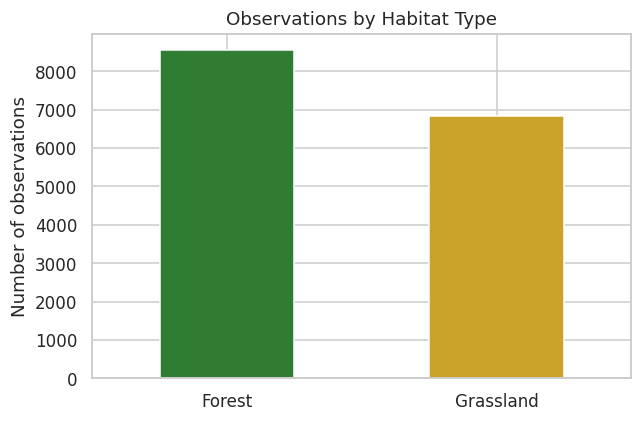

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df['Location_Type'].value_counts().plot(kind='bar', ax=ax, color=['#2e7d32', '#c9a227'])
ax.set_title('Observations by Habitat Type')
ax.set_xlabel('')
ax.set_ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Forest surveys recorded more total observations than Grassland (8,546 vs 6,826 after de-duplication), but as we'll see below, species *richness* tells a more nuanced story than raw observation volume.

## 3. Temporal Analysis

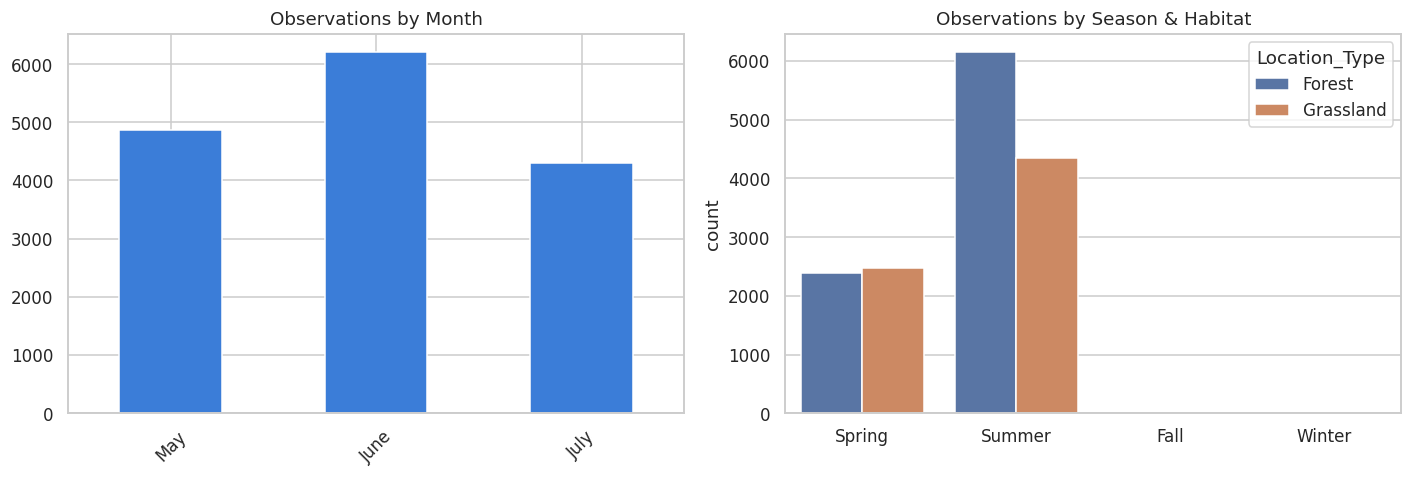

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_counts = df['Month_Name'].value_counts().reindex(month_order).dropna()
month_counts.plot(kind='bar', ax=axes[0], color='#3b7dd8')
axes[0].set_title('Observations by Month')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Season', order=['Spring','Summer','Fall','Winter'],
              hue='Location_Type', ax=axes[1])
axes[1].set_title('Observations by Season & Habitat')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


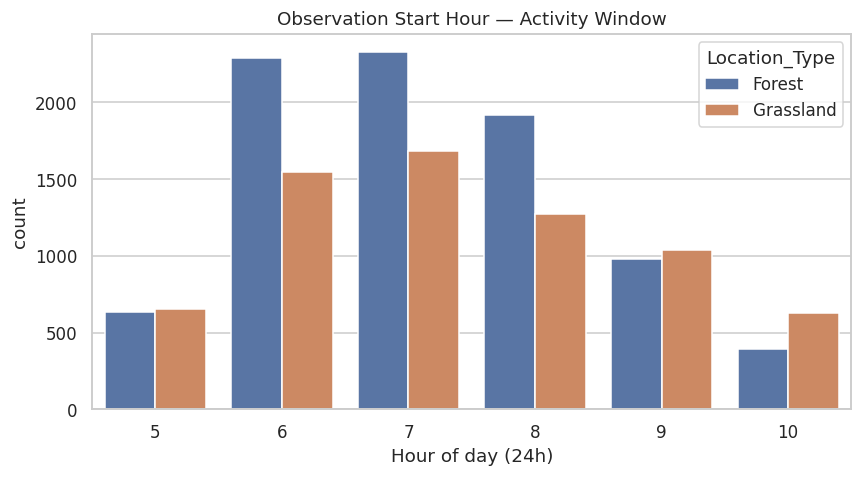

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df.dropna(subset=['Start_Hour']), x='Start_Hour',
              hue='Location_Type', ax=ax)
ax.set_title('Observation Start Hour — Activity Window')
ax.set_xlabel('Hour of day (24h)')
plt.tight_layout()
plt.show()


**Insight:** Surveys are concentrated in the **breeding season (spring into summer)**, consistent with standard point-count protocol. Nearly all observation sessions start in the **early morning (roughly 5–9 AM)** — the peak bird-activity window — with very few sessions later in the day.

## 4. Spatial Analysis (Admin Unit / Plot level)

*No latitude/longitude columns exist in the source data*, so spatial analysis here is done at the Admin Unit (park) and Plot level rather than on a literal map — the Streamlit dashboard also treats this consistently.

In [9]:
unit_div = df.groupby('Admin_Unit_Code').agg(
    Observations=('Common_Name', 'size'),
    Species_Richness=('Common_Name', 'nunique'),
    Plots=('Plot_Name', 'nunique')
).sort_values('Species_Richness', ascending=False)
unit_div


,Observations,Species_Richness,Plots
Admin_Unit_Code,,,
MONO,2522,99,83
CHOH,2202,80,90
ANTI,3463,80,99
MANA,1901,80,68
NACE,684,66,29
PRWI,2463,54,132
HAFE,530,54,23
GWMP,386,49,20
CATO,805,46,45


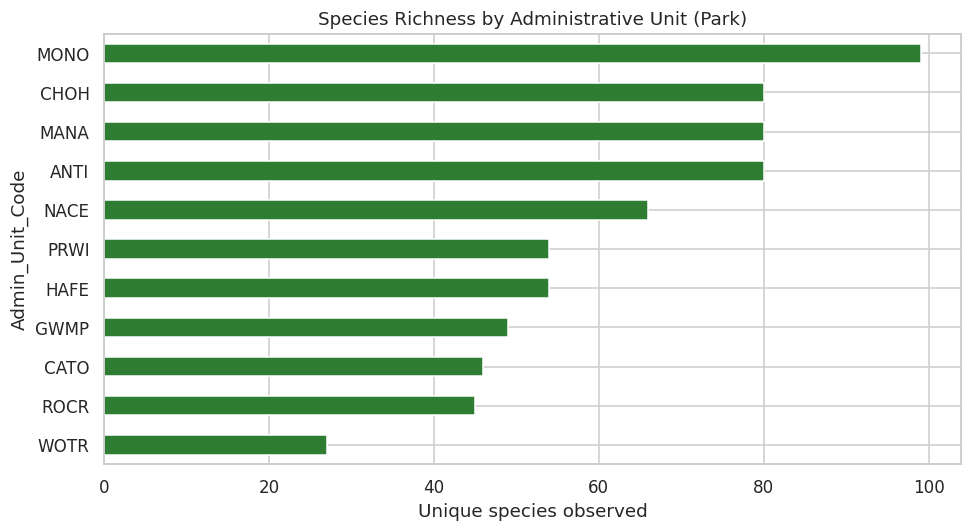

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
unit_div['Species_Richness'].sort_values().plot(kind='barh', ax=ax, color='#2e7d32')
ax.set_title('Species Richness by Administrative Unit (Park)')
ax.set_xlabel('Unique species observed')
plt.tight_layout()
plt.show()


In [11]:
top_plots = (df.groupby(['Admin_Unit_Code', 'Plot_Name'])['Common_Name']
             .nunique().sort_values(ascending=False).head(10))
top_plots.rename('Unique species').to_frame()


Unique species
Admin_Unit_Code Plot_Name                
MONO            MONO-0057              27
MANA            MANA-0047              27
ANTI            ANTI-0105              27
CHOH            CHOH-0812              26
MONO            MONO-0085              26
                MONO-0066              26
                MONO-0076              26
MANA            MANA-0048              26
ANTI            ANTI-0009              25
                ANTI-0160              25

**Insight:** Species richness (biodiversity) varies noticeably by park, and the ranking by richness is **not the same** as the ranking by raw observation count — some units get many observations of relatively few species, while others show a wider mix. These are the candidate **biodiversity hotspots** for conservation prioritisation.

## 5. Species Analysis

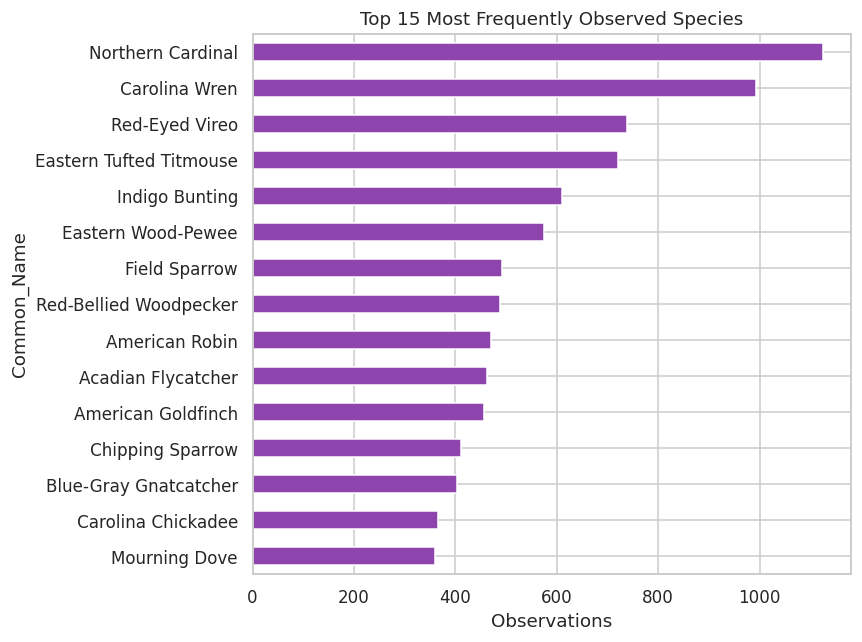

In [12]:
top_species = df['Common_Name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_species.sort_values().plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Top 15 Most Frequently Observed Species')
ax.set_xlabel('Observations')
plt.tight_layout()
plt.show()


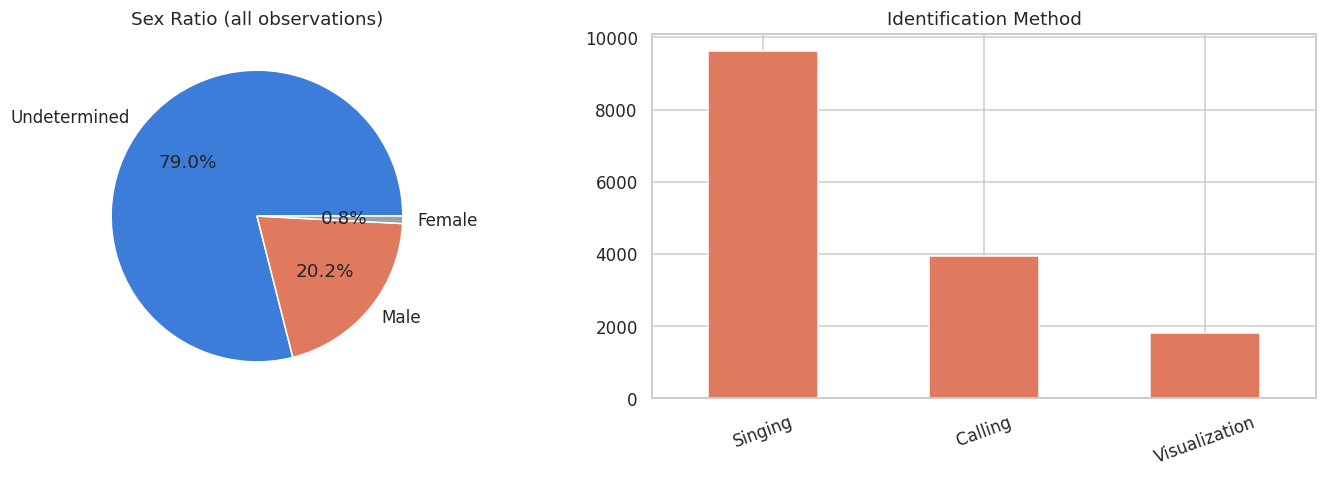

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sex_counts = df['Sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#3b7dd8', '#e07a5f', '#94a3a8'])
axes[0].set_title('Sex Ratio (all observations)')

id_counts = df['ID_Method'].value_counts()
id_counts.plot(kind='bar', ax=axes[1], color='#e07a5f')
axes[1].set_title('Identification Method')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Insight:** A large share of birds are recorded as **'Undetermined'** sex — expected, since most detections are auditory (song/call) rather than visual, which is confirmed by `ID_Method` being dominated by **Singing/Calling** over direct **Visualization**.

## 6. Environmental Conditions

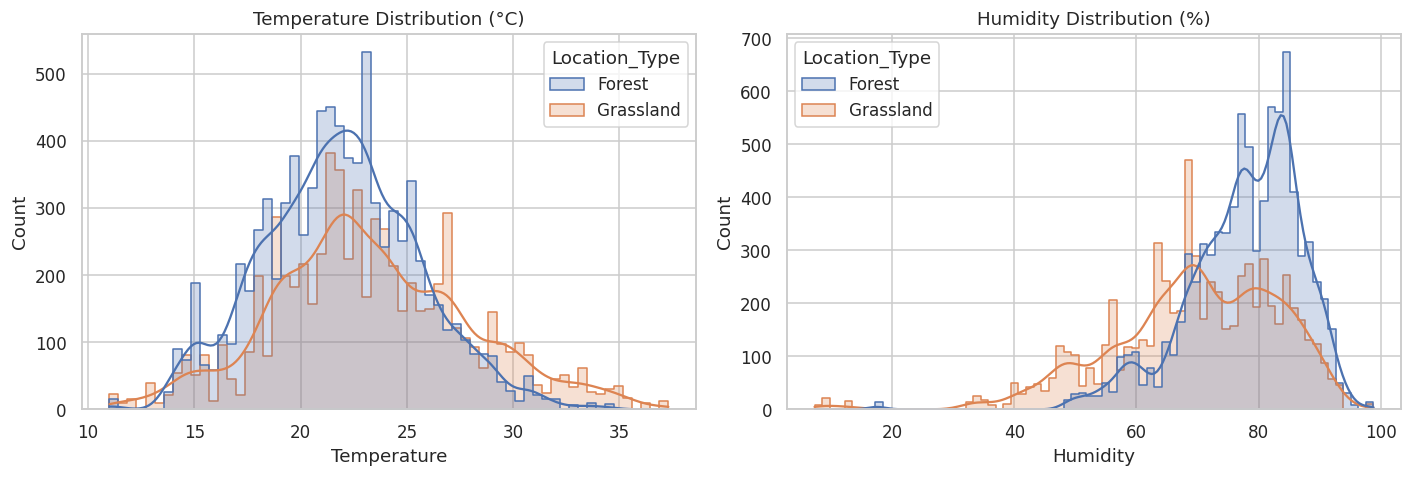

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=df, x='Temperature', hue='Location_Type', kde=True,
             ax=axes[0], element='step')
axes[0].set_title('Temperature Distribution (°C)')

sns.histplot(data=df, x='Humidity', hue='Location_Type', kde=True,
             ax=axes[1], element='step')
axes[1].set_title('Humidity Distribution (%)')
plt.tight_layout()
plt.show()


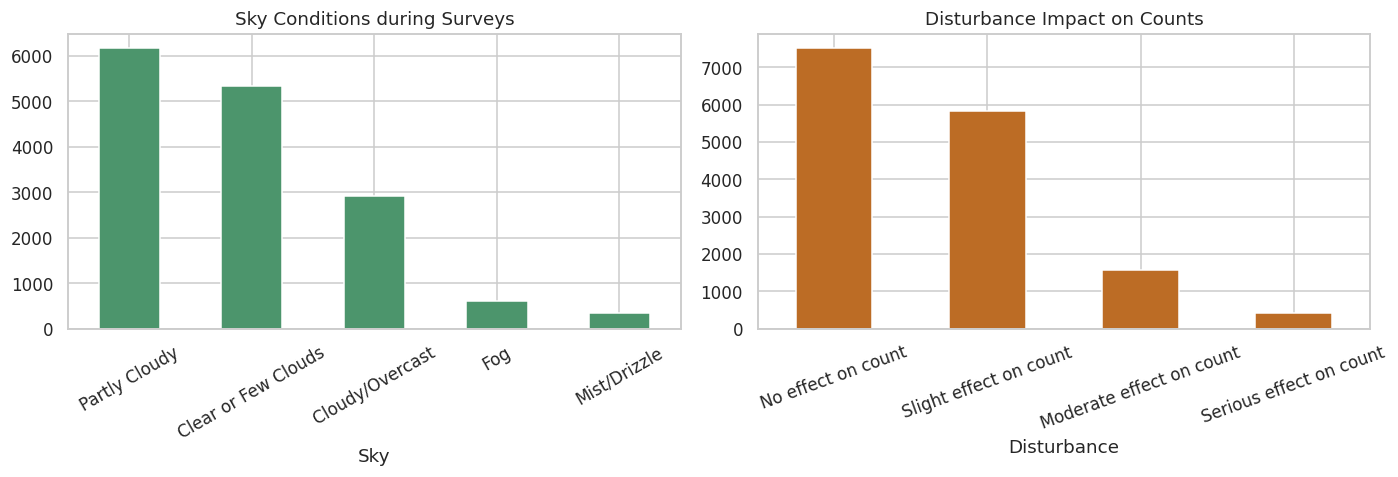

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sky_counts = df['Sky'].value_counts()
sky_counts.plot(kind='bar', ax=axes[0], color='#4c956c')
axes[0].set_title('Sky Conditions during Surveys')
axes[0].tick_params(axis='x', rotation=30)

disturbance_counts = df['Disturbance'].value_counts()
disturbance_counts.plot(kind='bar', ax=axes[1], color='#bc6c25')
axes[1].set_title('Disturbance Impact on Counts')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


**Insight:** The vast majority of surveys report **'No effect on count'** for disturbance, meaning most of the data is high-confidence for trend analysis. Surveys skew toward clear/partly-cloudy skies with mild wind — consistent with standardised protocol requiring good observing conditions.

## 7. Distance & Behaviour

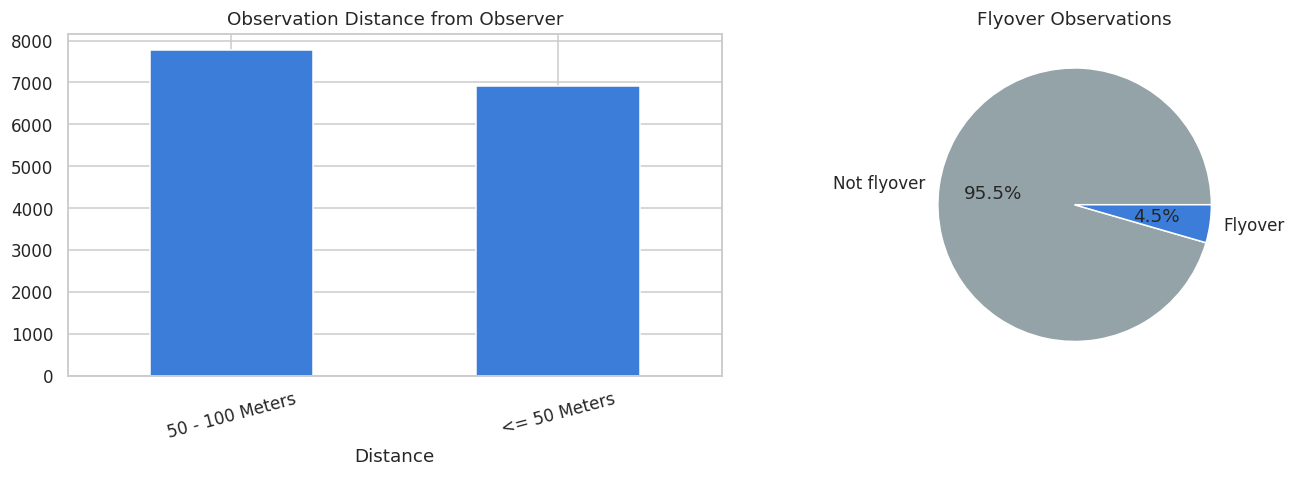

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dist_counts = df['Distance'].value_counts()
dist_counts.plot(kind='bar', ax=axes[0], color='#3b7dd8')
axes[0].set_title('Observation Distance from Observer')
axes[0].tick_params(axis='x', rotation=15)

flyover = df['Flyover_Observed'].value_counts()
axes[1].pie(flyover, labels=[f"{'Flyover' if v else 'Not flyover'}" for v in flyover.index],
            autopct='%1.1f%%', colors=['#94a3a8', '#3b7dd8'])
axes[1].set_title('Flyover Observations')
plt.tight_layout()
plt.show()


**Insight:** Most detections happen within 100 meters of the observer, and flyovers (birds passing overhead rather than using the plot habitat) are a small minority of records — meaning most observations genuinely reflect habitat use rather than incidental transit.

## 8. Observer Trends

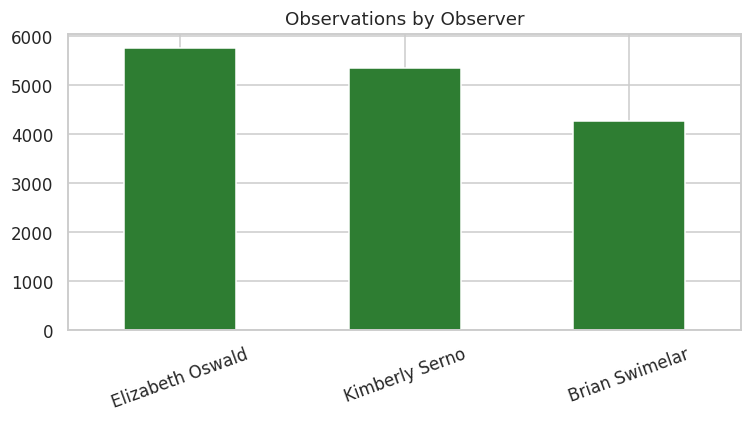

,Unique species logged
Observer,
Elizabeth Oswald,119
Kimberly Serno,90
Brian Swimelar,83


In [17]:
obs_counts = df['Observer'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
obs_counts.plot(kind='bar', ax=ax, color='#2e7d32')
ax.set_title('Observations by Observer')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

obs_species = df.groupby('Observer')['Common_Name'].nunique().sort_values(ascending=False)
obs_species.rename('Unique species logged').to_frame()


**Insight:** A small number of observers account for most records — worth flagging as **potential observer bias** (some individuals may be more active, or better at auditory ID) when comparing site-level diversity over time.

## 9. Conservation Insights

In [18]:
watchlist = df[df['PIF_Watchlist_Status'] == True]
print(f"Observations of PIF Watchlist (at-risk) species: {len(watchlist):,} "
      f"({len(watchlist)/len(df)*100:.1f}% of all observations)")

watchlist_species = (watchlist.groupby(['Common_Name', 'Location_Type'])
                      .size().reset_index(name='Observations')
                      .sort_values('Observations', ascending=False))
watchlist_species.head(15)


Observations of PIF Watchlist (at-risk) species: 378 (2.5% of all observations)


,Common_Name,Location_Type,Observations
8,Wood Thrush,Forest,290
10,Worm-Eating Warbler,Forest,31
9,Wood Thrush,Grassland,19
5,Prairie Warbler,Grassland,18
4,Prairie Warbler,Forest,7
1,Cerulean Warbler,Forest,7
7,Willow Flycatcher,Grassland,2
2,Kentucky Warbler,Forest,1
0,Blue-Winged Warbler,Forest,1
6,Red-Headed Woodpecker,Forest,1


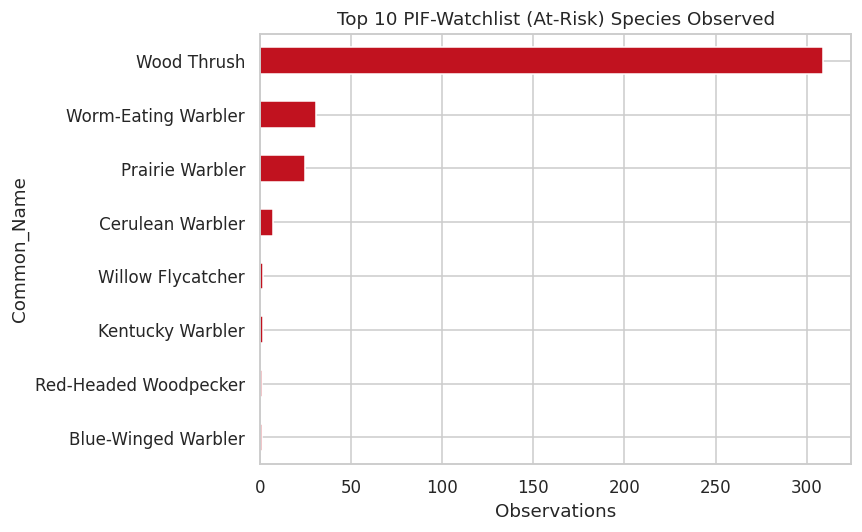

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
top_watchlist = watchlist['Common_Name'].value_counts().head(10)
top_watchlist.sort_values().plot(kind='barh', ax=ax, color='#c1121f')
ax.set_title('Top 10 PIF-Watchlist (At-Risk) Species Observed')
ax.set_xlabel('Observations')
plt.tight_layout()
plt.show()


**Insight:** These are the species that most warrant **targeted conservation attention** — they combine a formal at-risk designation with enough observation volume in this dataset to support monitoring.

## 10. Key Takeaways

1. **Habitat differences are real but nuanced** — Forest has more raw observations, but species richness per park doesn't map 1:1 onto observation volume, so both metrics matter for conservation planning.
2. **Surveys are heavily concentrated in early-morning, breeding-season windows** — any year-over-year comparison should control for this to avoid conflating survey effort with real population change.
3. **Most detections are auditory**, so `ID_Method` and `Sex` ('Undetermined') patterns reflect detection method as much as biology.
4. **A handful of parks/plots stand out as biodiversity hotspots** — good first candidates for eco-tourism / habitat protection focus.
5. **PIF Watchlist species are a small but trackable subset** of observations — worth a dedicated conservation-monitoring view (built into the dashboard's 'Conservation' tab).
6. **Observer effort is uneven**, which should be considered a confounder before attributing site differences purely to habitat quality.

---
*Continue to the Streamlit dashboard (`app.py`) for an interactive, filterable version of all of the above — including the ability to upload new/updated survey workbooks and regenerate the dashboard on the fly.*